In [159]:
import json, os, math
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pickle
from collections import Counter, defaultdict
import pandas as pd
import re
from scipy.stats import pearsonr
from wordcloud import WordCloud



FILE_URL = 'repos_top_100_stars_enriched.json'
GRAPH_FILE = 'repo_collab_graph.pkl'


# Creating the graph

We ensure that no duplicates nodes are found in the graph. We chose to include repos that have no main language and mark their language as "Misc" for "Miscellaneous". This is done when the data was first generated via another Python script (github_scrape_top_stars.py) and the filtering on language here is a fallback.

In [ ]:
if os.path.exists(GRAPH_FILE):
    print(f"Loading graph from {GRAPH_FILE}")
    with open(GRAPH_FILE, "rb") as f:
        G = pickle.load(f)
    print(f"Loaded graph from {GRAPH_FILE}")

else:
    with open(FILE_URL, "r") as f:
        data = f.read()
    data = json.loads(data)

    G = nx.Graph()

    #Add all nodes first
    for key in data:
        language = key['language']
        if language is None:
            continue
        G.add_node(
            key["repository"],
            language=language,
            stars=key['stars'],
            forks=key['forks'],
            authors=set(key['contributors']),
            num_collab=key["number_of_collaborators"],
            read_me=key["readme"]
        )

    #Add edges (only once, after all nodes exist)
    repos = list(G.nodes())
    for i in range(len(repos)):
        for j in range(i + 1, len(repos)):
            r1, r2 = repos[i], repos[j]
            common = G.nodes[r1]["authors"] & G.nodes[r2]["authors"]
            if common:
                G.add_edge(r1, r2, weight=len(common), shared=list(common))


#Find isolates
isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)}")


G_connected = G.copy()
G_connected.remove_nodes_from(isolates)

with open('github_network.pkl', 'wb') as f:
    pickle.dump(G_connected, f)


Isolated nodes: 9


# Plotting the degree distribution (not used)

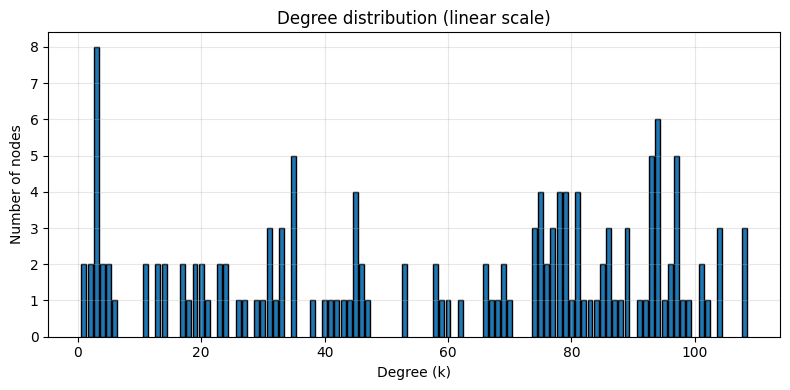

In [161]:
degrees = [d for _, d in G_connected.degree()]
if len(degrees) == 0:
    raise RuntimeError("Graph `G` has no nodes/edges.")

deg_count = Counter(degrees)
deg_items = sorted(deg_count.items())    # list of (degree, count)
ks, counts = zip(*deg_items)
ks = np.array(ks)
counts = np.array(counts)

# 1) Linear bar histogram of degree counts
plt.figure(figsize=(8,4))
plt.bar(ks, counts, width=0.8, color='C0', edgecolor='k')
plt.xlabel('Degree (k)')
plt.ylabel('Number of nodes')
plt.title('Degree distribution (linear scale)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Degree distribution vs. BA model

In [ ]:
n = G_connected.number_of_nodes()
avg_degree = np.mean([d for n, d in G_connected.degree()])

m = int(avg_degree / 2)

print(f"Your network: {n} nodes, avg degree: {avg_degree:.2f}")
print(f"BA parameters: n={n}, m={m}")

# Generate comparable BA model
G_ba = nx.barabasi_albert_graph(n, m)

Your network: 148 nodes, avg degree: 57.49
BA parameters: n=148, m=28


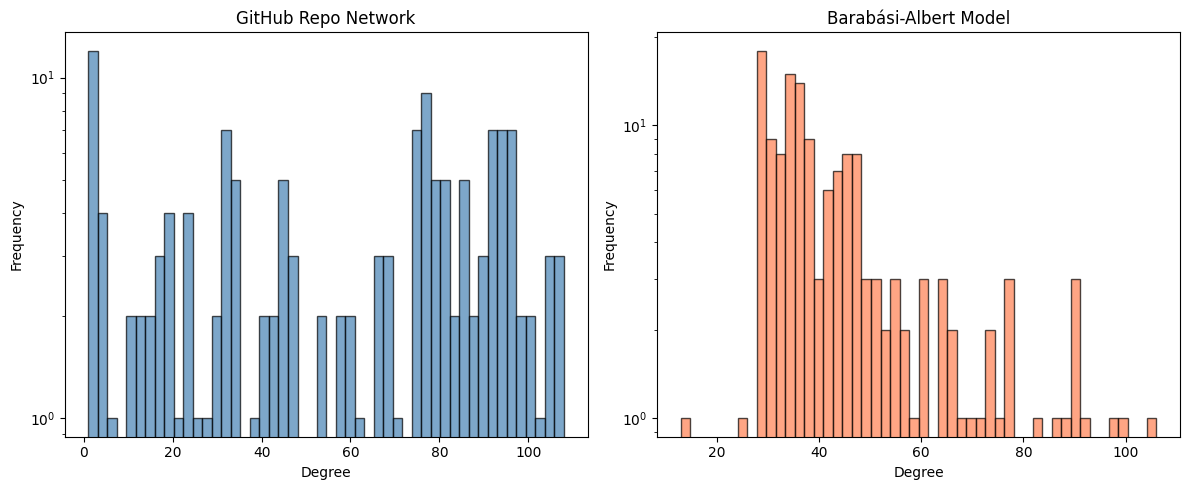

In [ ]:
#Get degree sequences
degrees_real = [d for n, d in G_connected.degree()]
degrees_ba = [d for n, d in G_ba.degree()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#Your network
ax1.hist(degrees_real, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Frequency')
ax1.set_title('GitHub Repo Network')
ax1.set_yscale('log')

#BA model
ax2.hist(degrees_ba, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Degree')
ax2.set_ylabel('Frequency')
ax2.set_title('Barabási-Albert Model')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('degree_comparison_ba.png')
plt.show()

## Degree probability distribution (not used)

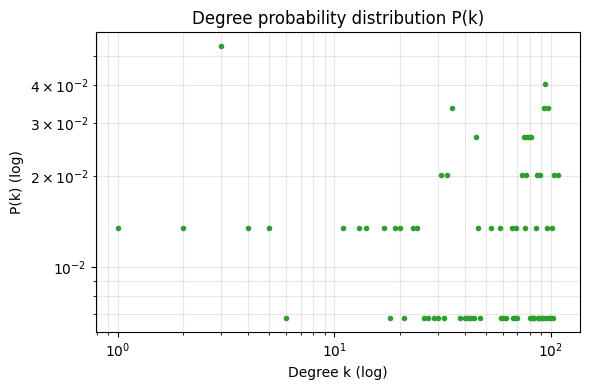

In [164]:
nonzero = ks > 0
k_nz = ks[nonzero]
c_nz = counts[nonzero]

plt.figure(figsize=(6,4))
p_k = counts / counts.sum()
plt.loglog(ks[nonzero], p_k[nonzero], marker='.', linestyle='none', color='C2')
plt.xlabel('Degree k (log)')
plt.ylabel('P(k) (log)')
plt.title('Degree probability distribution P(k)')
plt.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Key Metrics

In [ ]:
degrees = [d for n, d in G_connected.degree()]
print(f"\n=== Connected Component ===")
print(f"Nodes: {G_connected.number_of_nodes()}")
print(f"Edges: {G_connected.number_of_edges()}")
density = nx.density(G)
print(f"Density: {density:.4f}")
print(f"Avg degree: {np.mean(degrees):.2f}")
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")
print(f"Std deviation: {np.std(degrees):.2f}")
avg_path_length = nx.average_shortest_path_length(G_connected)
diameter = nx.diameter(G_connected)
print(f"Average Shortest Path Length: {avg_path_length:.4f}")
print(f"Diameter: {diameter}")

#Average edge weight (shared contributors)
if nx.is_weighted(G_connected):
    weights = [d['weight'] for u, v, d in G_connected.edges(data=True)]
    print(f"Avg Edge Weight: {np.mean(weights):.2f}")
    print(f"Max Edge Weight: {max(weights)}")
    print(f"Min Edge Weight: {min(weights)}")

unique_contributors = set()

for node, attrs in G_connected.nodes(data=True):
    authors = attrs.get("authors", 0)
    if isinstance(authors, (set, list, tuple)):
        unique_contributors |= set(authors)
    else:
        unique_contributors.add(authors)

print(f"Unique user names across all repositories: {len(unique_contributors)}")


=== Connected Component ===
Nodes: 148
Edges: 4254
Density: 0.3474
Avg degree: 57.49
Max degree: 108
Min degree: 1
Std deviation: 33.46
Average Shortest Path Length: 1.7669
Diameter: 6
Avg Edge Weight: 2.04
Max Edge Weight: 217
Min Edge Weight: 1
Unique user names across all repositories: 55619


# Centrality, betweenneess, eigenvectors and closeness (Only centrality used)

In [ ]:
#add raw degree (count) and strength (sum of weights) to centrality_df
#G_connected: your NetworkX graph
n = G_connected.number_of_nodes()

#raw degree counts
degree_counts = dict(G_connected.degree())         

#weighted degree / node strength (if edges have 'weight')
strength = {node: sum(d.get('weight', 1) for _, _, d in G_connected.edges(node, data=True))
            for node in G_connected.nodes()}


#Calculate centrality measures
degree_cent = nx.degree_centrality(G_connected)
print(f"Calculated degree centrality for {len(degree_cent)} nodes.")
betweenness_cent = nx.betweenness_centrality(G_connected)
print(f"Calculated betweenness centrality for {len(betweenness_cent)} nodes.")
eigenvector_cent = nx.eigenvector_centrality(G_connected, max_iter=1000)
print(f"Calculated eigenvector centrality for {len(eigenvector_cent)} nodes.")
closeness_cent = nx.closeness_centrality(G_connected)
print(f"Calculated closeness centrality for {len(closeness_cent)} nodes.")

#Store in a DataFrame for easy analysis
centrality_df = pd.DataFrame({
    'repo': list(G_connected.nodes()),
    'degree': [degree_cent[n] for n in G_connected.nodes()],
    'betweenness': [betweenness_cent[n] for n in G_connected.nodes()],
    'eigenvector': [eigenvector_cent[n] for n in G_connected.nodes()],
    'closeness': [closeness_cent[n] for n in G_connected.nodes()],
    'stars': [G_connected.nodes[n].get('stars', 0) for n in G_connected.nodes()],
    'forks': [G_connected.nodes[n].get('forks', 0) for n in G_connected.nodes()],
    'language': [G_connected.nodes[n].get('language', 'Unknown') for n in G_connected.nodes()],
})

centrality_df['degree_count'] = centrality_df['repo'].map(degree_counts).fillna(0).astype(int)
centrality_df['degree_centrality'] = centrality_df['repo'].map(degree_cent).fillna(0.0)
centrality_df['strength'] = centrality_df['repo'].map(strength).fillna(0).astype(int)

print(centrality_df.nlargest(10, 'degree_count')[['repo', 'degree_count', 'degree_centrality', 'strength']])

Calculated degree centrality for 148 nodes.
Calculated betweenness centrality for 148 nodes.
Calculated eigenvector centrality for 148 nodes.
Calculated closeness centrality for 148 nodes.
                                      repo  degree_count  degree_centrality  \
8                           facebook/react           108           0.734694   
48                             nodejs/node           108           0.734694   
53                             axios/axios           108           0.734694   
55                           denoland/deno           104           0.707483   
67                        tauri-apps/tauri           104           0.707483   
78                       supabase/supabase           104           0.707483   
76                           neovim/neovim           102           0.693878   
81                     puppeteer/puppeteer           101           0.687075   
105                         python/cpython           101           0.687075   
61   microsoft/genera

In [167]:
def top_by_centrality(df, measure, n=10):
    print(f"\n=== Top {n} by {measure.upper()} ===")
    top = df.nlargest(n, measure)[['repo', measure, 'stars', 'language', 'forks']]
    for i, row in top.iterrows():
        print(f"{row['repo']:40} | {measure}: {row[measure]:.4f} | ⭐ {row['stars']:,} | Lang: {row['language']} | Forks: {row['forks']:,}")

top_by_centrality(centrality_df, 'degree')
top_by_centrality(centrality_df, 'betweenness')
top_by_centrality(centrality_df, 'eigenvector')
top_by_centrality(centrality_df, 'closeness')


=== Top 10 by DEGREE ===
facebook/react                           | degree: 0.7347 | ⭐ 241,413 | Lang: JavaScript | Forks: 50,038
nodejs/node                              | degree: 0.7347 | ⭐ 114,638 | Lang: JavaScript | Forks: 33,978
axios/axios                              | degree: 0.7347 | ⭐ 108,345 | Lang: JavaScript | Forks: 11,462
denoland/deno                            | degree: 0.7075 | ⭐ 105,491 | Lang: Rust | Forks: 5,824
tauri-apps/tauri                         | degree: 0.7075 | ⭐ 99,759 | Lang: Rust | Forks: 3,220
supabase/supabase                        | degree: 0.7075 | ⭐ 94,344 | Lang: TypeScript | Forks: 10,941
neovim/neovim                            | degree: 0.6939 | ⭐ 94,820 | Lang: Vim Script | Forks: 6,464
puppeteer/puppeteer                      | degree: 0.6871 | ⭐ 93,019 | Lang: TypeScript | Forks: 9,342
python/cpython                           | degree: 0.6871 | ⭐ 70,176 | Lang: Python | Forks: 33,622
microsoft/generative-ai-for-beginners    | degree: 0.6

## Centrality Correlations (not used)

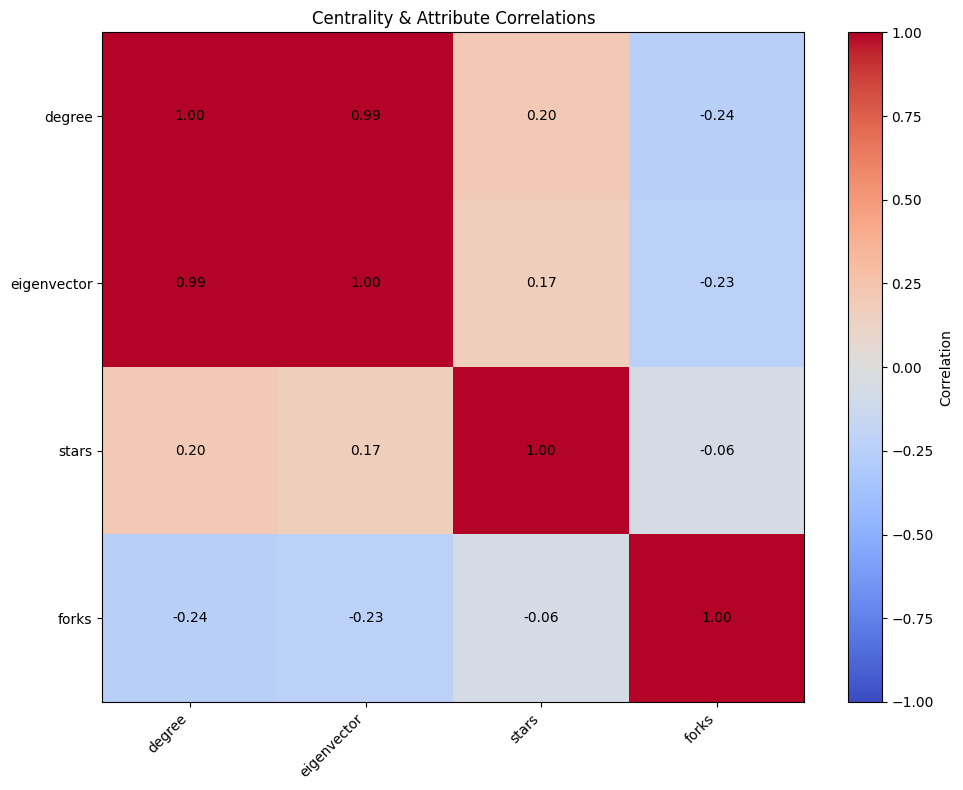

In [ ]:
#Correlation matrix
correlation_cols = ['degree', 'eigenvector', 'stars', 'forks']
corr_matrix = centrality_df[correlation_cols].corr()

#Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=45, ha='right')
plt.yticks(range(len(correlation_cols)), correlation_cols)

#Add correlation values
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', fontsize=10)

plt.title('Centrality & Attribute Correlations')
plt.tight_layout()
plt.savefig('centrality_correlation.png')
plt.show()

# Degree Assortativity (not used but added to key metrics)

Degree Assortativity: 0.0370


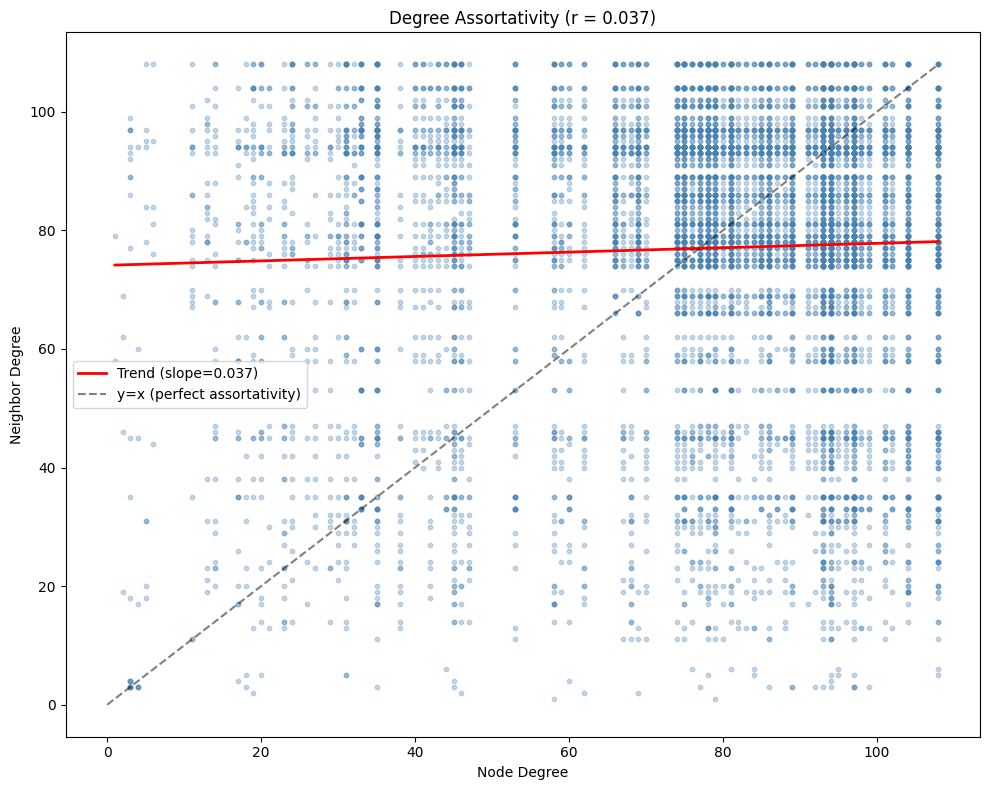

In [ ]:
#Calculate degree assortativity
degree_assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree Assortativity: {degree_assortativity:.4f}")
#The higher the value, the more likely nodes connect to others with similar degree.

#Get degree of each node and its neighbors
degree_dict = dict(G_connected.degree())

source_degrees = []
target_degrees = []

for u, v in G_connected.edges():
    source_degrees.append(degree_dict[u])
    target_degrees.append(degree_dict[v])
    # Add reverse since undirected
    source_degrees.append(degree_dict[v])
    target_degrees.append(degree_dict[u])

#Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(source_degrees, target_degrees, alpha=0.3, s=10, color='steelblue')

#Add trend line
z = np.polyfit(source_degrees, target_degrees, 1)
p = np.poly1d(z)
x_line = np.linspace(min(source_degrees), max(source_degrees), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend (slope={z[0]:.3f})')

#Add diagonal reference
max_val = max(max(source_degrees), max(target_degrees))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y=x (perfect assortativity)')

plt.xlabel('Node Degree')
plt.ylabel('Neighbor Degree')
plt.title(f'Degree Assortativity (r = {degree_assortativity:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('degree_assortativity.png')
plt.show()

# Communities (Not used) & Barchart for showing top languages by number of repositories and avg degree over programming language.

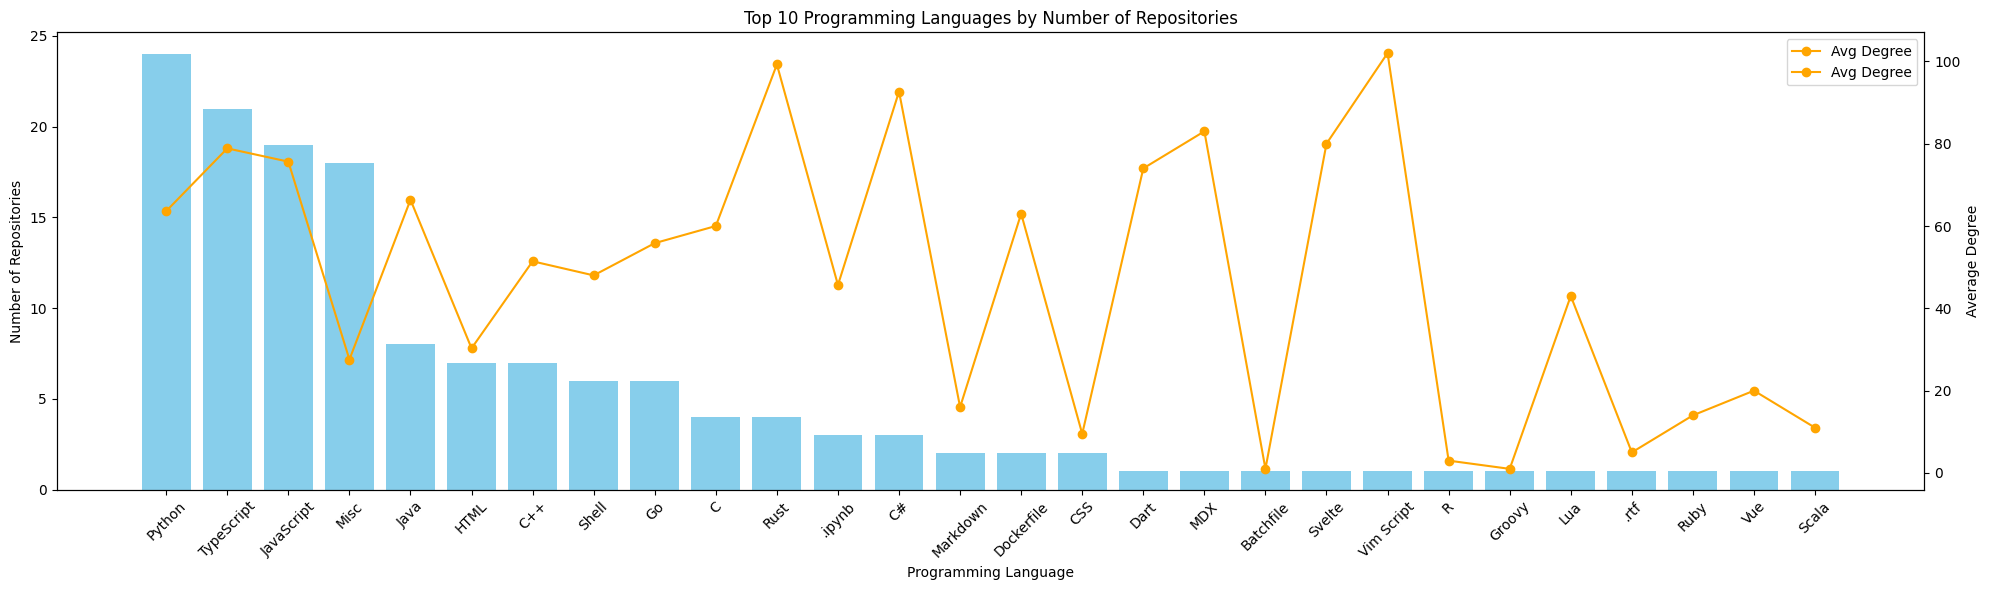

In [ ]:
community = nx.community.louvain_communities(G_connected, weight='weight')
sorted_communities = [community for community in community if len(community) > 1]
community_objects = sorted(sorted_communities, key=len, reverse=True)
for i, comm in enumerate(sorted_communities):
    # Find dominant language and purity
    langs = [G_connected.nodes[n].get("language", "Unknown") for n in comm]
    counts = Counter(langs)
    dominant_lang, dominant_count = counts.most_common(1)[0]
    purity = dominant_count / len(comm)

    community_object = {
        "size": len(comm),
        "languages": counts,
        "dominant_language": dominant_lang,
        "purity": purity,
        #"repos": list(comm),
    }

    community_objects[i] = community_object

sorted_communities = sorted(community_objects, key=lambda x: x.get("size", None), reverse=True)

#Find average degree based on language
language_degrees = {}
for node, attrs in G_connected.nodes(data=True):
    lang = attrs.get("language", "Unknown")
    if lang == "Jupyter Notebook":
        lang = ".ipynb"
    elif lang == "Rich Text Format":
        lang = ".rtf"
    degree = G_connected.degree(node)
    if lang not in language_degrees:
        language_degrees[lang] = []
    language_degrees[lang].append(degree)

#print("\nAverage degree by programming language:")
for lang, degrees in language_degrees.items():
    avg_degree = sum(degrees) / len(degrees)
    #print(f"  {lang}: {avg_degree:.2f}")

#Top languages based on number of repos
lang_counter = Counter()
for node, attrs in G_connected.nodes(data=True):
    lang = attrs.get("language", "Unknown")
    if lang == "Jupyter Notebook":
        lang = ".ipynb"
    elif lang == "Rich Text Format":
        lang = ".rtf"
    if lang is not None:
        lang_counter[lang] += 1

#Bar chart showing language popularity with line showing degree for language
plt.figure(figsize=(20, 6))
langs, counts = zip(*lang_counter.most_common(30))
plt.bar(langs, counts, color='skyblue')
plt.xlabel('Programming Language')
plt.ylabel('Number of Repositories')
plt.title('Top 10 Programming Languages by Number of Repositories')
plt.xticks(rotation=45)
ax2 = plt.gca().twinx()
avg_degrees = [np.mean(language_degrees[lang]) for lang in langs]
ax2.plot(langs, avg_degrees, color='orange', marker='o', label='Avg Degree')
ax2.set_ylabel('Average Degree')
lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper right')
plt.tight_layout()
plt.show()

#print("\nTop programming languages by number of repositories:")
#for lang, count in lang_counter.most_common(30):
#    print(f"  {lang}: {count} repositories")



# Person correlation factor

In [171]:
#Extract language data from nodes
language_counts = defaultdict(int)
language_degrees = defaultdict(list)

for node, attrs in G_connected.nodes(data=True):
    lang = attrs.get('language', 'Unknown')  # adjust key name if needed
    degree = G_connected.degree(node)

    language_counts[lang] += 1
    language_degrees[lang].append(degree)

#Calculate average degree per language
languages = list(language_counts.keys())
repo_counts = [language_counts[lang] for lang in languages]
avg_degrees = [np.mean(language_degrees[lang]) for lang in languages]

#Pearson correlation
correlation, p_value = pearsonr(repo_counts, avg_degrees)

print(f"Pearson correlation: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation: 0.260
P-value: 0.1811


# README Analysis

## Splitting text and categorizing in terms of language.

Note that a few regexs have been used to remove unwanted syntax and such in the READMEs.

In [ ]:
readmes_to_lang = {}
for node, attrs in G_connected.nodes(data=True):
    readme = attrs.get("read_me", "")
    if readme:
        #Use regex to remove markdown formatting
        lang = attrs.get("language", "Unknown")
        formatted_text = readme
        #Remove URLs
        formatted_text = re.sub(r'https?://\S+', ' ', formatted_text)
        #Remove Markdown links
        formatted_text = re.sub(r'\[.*?\]\(.*?\)', ' ', formatted_text)
        #Remove markdown formatting and special chars
        formatted_text = re.sub(r'[#_*`>\-\[\]\(\)!~]', ' ', formatted_text)
        #Replace multiple spaces/newlines with one
        formatted_text = re.sub(r'\s+', ' ', formatted_text)

        #Find only words with 4 or more letters using regex
        collected_words = re.findall(r'\b[a-zA-Z]{5,}\b', formatted_text.lower())

        readmes_to_lang[lang] = readmes_to_lang.get(lang, "") + " " + " ".join(collected_words)

#Map how frequent words are used per language
freq_to_lang = {}
for lang, text in readmes_to_lang.items():
    freq_word_to_lang = {}
    for word in text.split():
        freq_word_to_lang[word] = freq_word_to_lang.get(word, 0) + 1
    freq_to_lang[lang] = freq_word_to_lang



In [173]:
with open("language_frequent_words.json", "w", encoding="utf-8") as f:
    json.dump(freq_to_lang, f, indent=4)

## Calculating TF-IDF (not used)

In [174]:
word_in_languages = defaultdict(set)
for lang, lang_freqs in freq_to_lang.items():
    for word in lang_freqs.keys():
        word_in_languages[word].add(lang)

total_languages = len(freq_to_lang)
word_idf = {}

for word, lang_set in word_in_languages.items():
    idf = math.log(total_languages / len(lang_set))
    word_idf[word] = idf

lang_tfidf = {}

for lan, word_freqs in freq_to_lang.items():
    tfidf_scores = {}
    total_words_in_lang = sum(word_freqs.values())
    for word, freq in word_freqs.items():
        # TF
        tf = freq / total_words_in_lang

        #TF IDF = TF * IDF
        idf = word_idf.get(word, 0)
        tfidf = tf * idf
        tfidf_scores[word] = tfidf
    lang_tfidf[lan] = tfidf_scores

# for lang, tfidf_scores in lang_tfidf.items():
#     sorted_tfidf = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:2]
#     print(f"\nTop words for {lang} by TF-IDF:")
#     for word, score in sorted_tfidf:
#         print(f"  {word}: {score:.6f}")

## WordClouds for top 3 programming languages based on degree (not used)

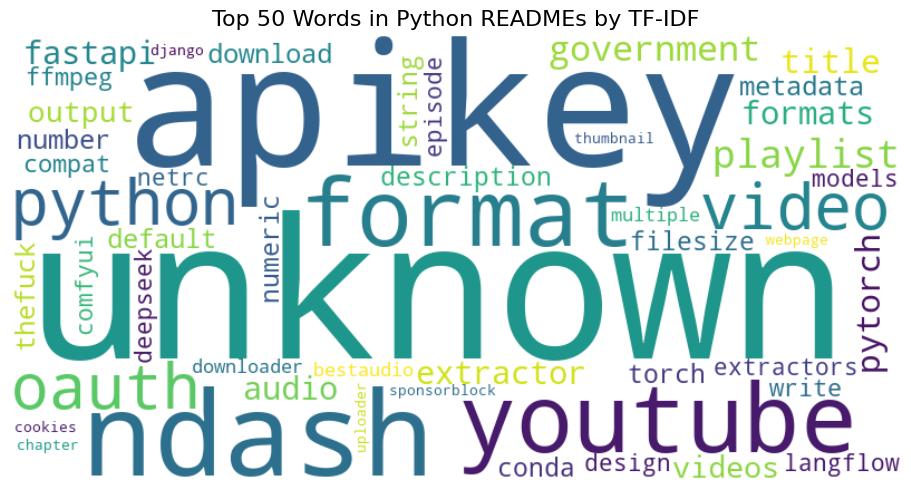

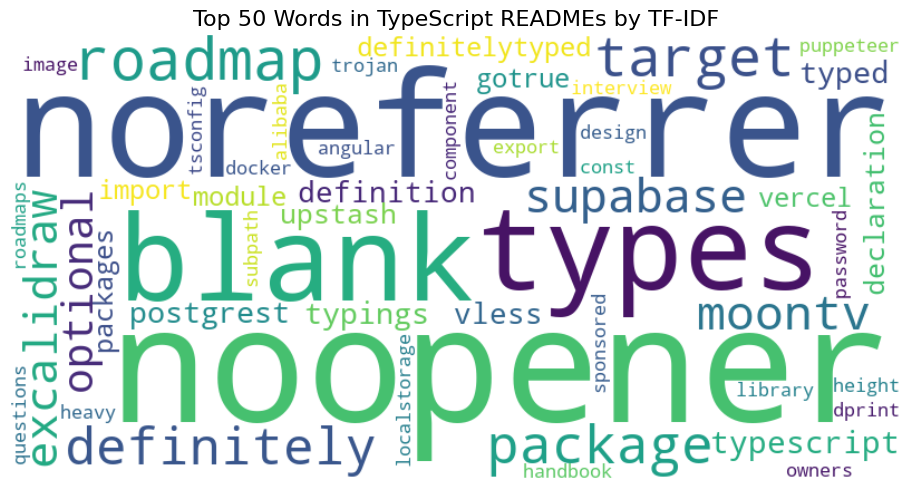

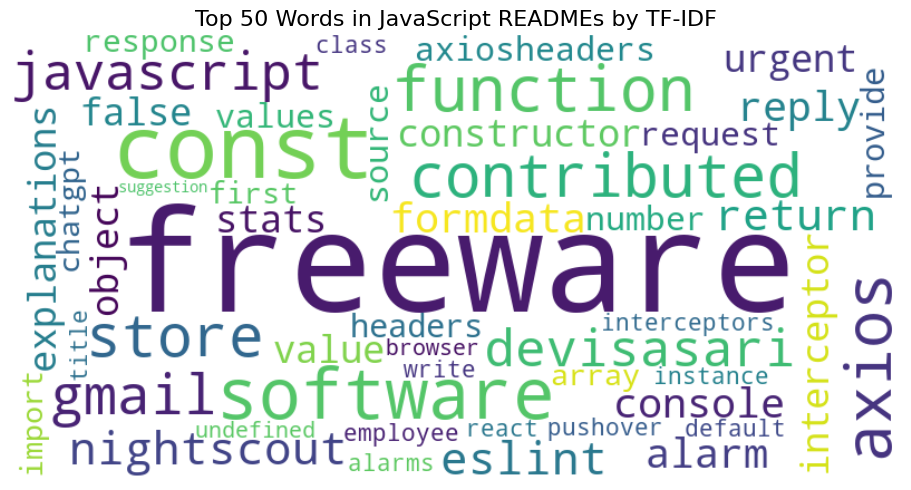

In [175]:
def create_lang_wordcloud(lang, tfidf_scores, top_n=100):
    if lang not in tfidf_scores:
        print(f"No TF-IDF scores found for language: {lang}")
        return
    
    scores = tfidf_scores[lang]
    top_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    scaled_scores = {word: score * 1000 for word, score in top_words}  # Scale for better visualization
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=top_n
    ).generate_from_frequencies(scaled_scores)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top {top_n} Words in {lang} READMEs by TF-IDF', fontsize=16)
    plt.tight_layout()
    plt.show()

# get top 3 languages

for lang in lang_counter.most_common(3):
    create_lang_wordcloud(lang[0], lang_tfidf, top_n=50)

## Sentiment based on repo.


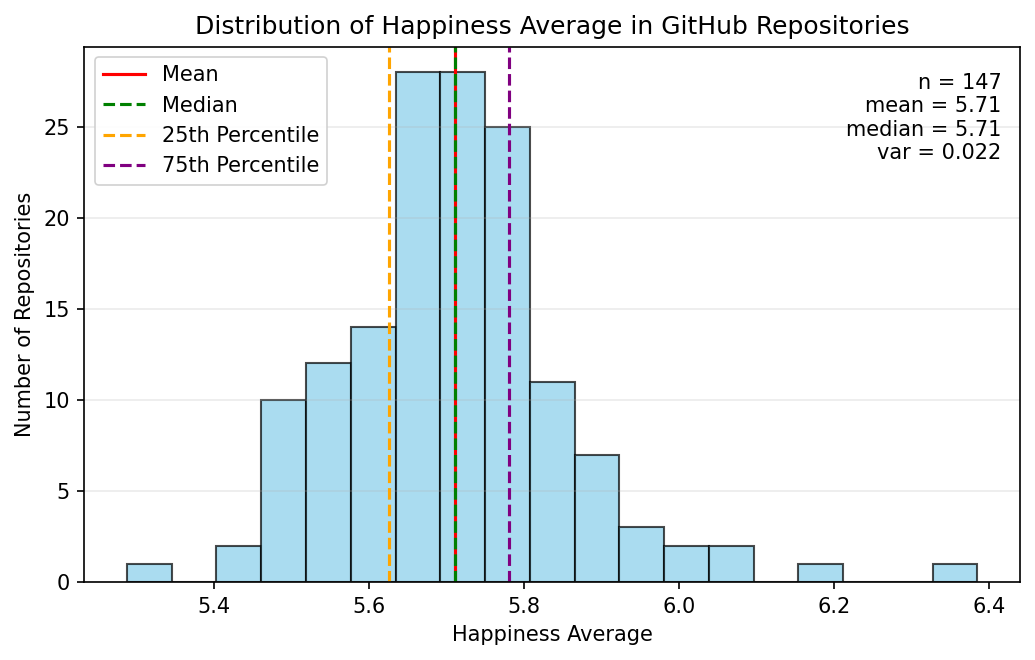

In [ ]:
#Calculate happiness_average and save to each node.

df = pd.read_csv("Data_Set_S1.txt", sep="\t", encoding="utf-8")
word_happiness = {}
for entry in df.itertuples():
    word = entry.word
    happiness_avg = entry.happiness_average
    #print(f"Word: {word}, Happiness Average: {happiness_avg}")
    word_happiness[word] = happiness_avg

for node in G_connected.nodes():
    readme = G_connected.nodes[node].get("read_me", "")
    if readme:
        words = re.findall(r'\b[a-zA-Z]{4,}\b', readme.lower())
        happiness_scores = [word_happiness[word] for word in words if word in word_happiness]
        if happiness_scores:
            avg_happiness = sum(happiness_scores) / len(happiness_scores)
            G_connected.nodes[node]["happiness_average"] = avg_happiness
        else:
            G_connected.nodes[node]["happiness_average"] = None
    else:
        G_connected.nodes[node]["happiness_average"] = None

sent_attr = "happiness_average"
vals = [d.get(sent_attr) for _, d in G_connected.nodes(data=True)]
vals = np.array([v for v in vals if v is not None], dtype=float)
if vals.size == 0:
    raise RuntimeError("No nodes with happiness_average attribute found.")

#Values for legend and vertical lines
mean_happiness = np.mean(vals)
median_happiness = np.median(vals)
p25_happiness = np.percentile(vals, 25)
p75_happiness = np.percentile(vals, 75)
var_happiness = np.var(vals)
n = len(vals)

#Bins for histogram
try:
    bin_edges = np.histogram_bin_edges(vals, bins='fd')
except Exception as e:
    print(f"Error calculating histogram bin edges: {e}")
    bin_edges = np.histogram_bin_edges(vals, bins='sqrt')

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

#Creation of plot
ax.hist(vals, bins=bin_edges, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(mean_happiness, color='red', linestyle='-', linewidth=1.5, label='Mean')
ax.axvline(median_happiness, color='green', linestyle='--', linewidth=1.5, label='Median')
ax.axvline(p25_happiness, color='orange', linestyle='dashed', linewidth=1.5, label='25th Percentile')
ax.axvline(p75_happiness, color='purple', linestyle='dashed', linewidth=1.5, label='75th Percentile')

ax.set_xlabel('Happiness Average')
ax.set_ylabel('Number of Repositories')
ax.set_title('Distribution of Happiness Average in GitHub Repositories')

ax.grid(True, axis="y", alpha=0.25)
leg = ax.legend(loc='upper left', frameon=True, framealpha=0.9)
leg.get_frame().set_linewidth(0.8)

text = f"n = {n}\nmean = {mean_happiness:.2f}\nmedian = {median_happiness:.2f}\nvar = {var_happiness:.3f}"
ax.text(0.98, 0.95, text, transform=ax.transAxes, ha="right", va="top")
plt.tight_layout()
plt.savefig('happiness_average_distribution.png')
plt.show()


## Sentiment based on language

C:\Users\lucas\AppData\Local\Temp\ipykernel_56256\3543581369.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('RdYlGn')


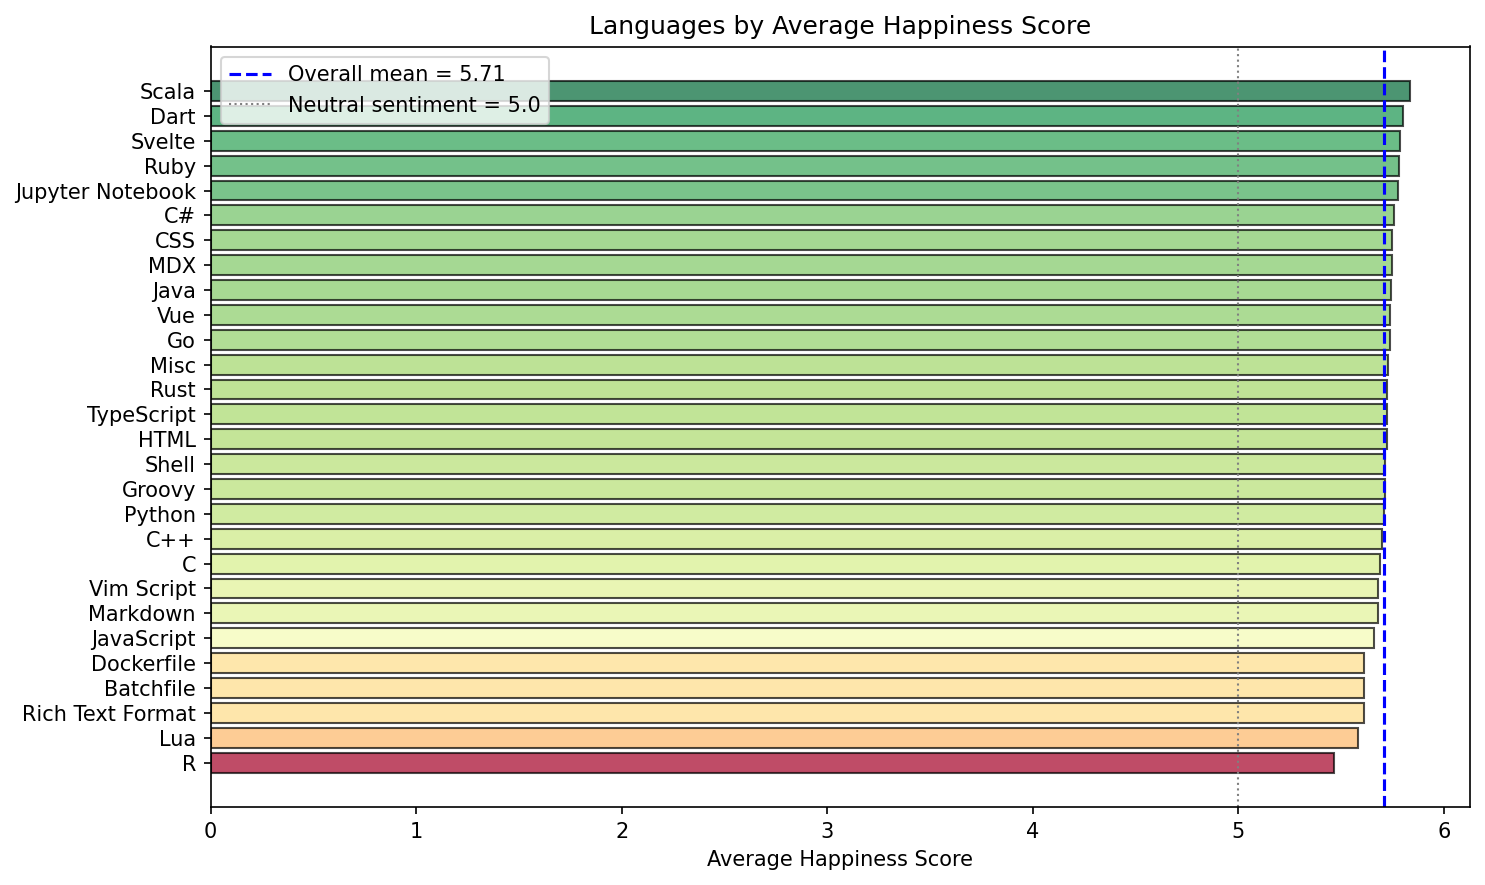

In [ ]:
#Average sentiment by language
lang_sentiment = []
for node, attrs in G_connected.nodes(data=True):
    lang = attrs.get("language", "Unknown")
    happiness = attrs.get("happiness_average", None)
    if happiness is not None:
        lang_sentiment.append((lang, happiness))

avg_sentiment_by_lang = {}
for lang in lang_sentiment:
    lang_name = lang[0]
    happiness = lang[1]
    if lang_name not in avg_sentiment_by_lang:
        avg_sentiment_by_lang[lang_name] = []
    avg_sentiment_by_lang[lang_name].append(happiness)

for lang in avg_sentiment_by_lang:
    scores = avg_sentiment_by_lang[lang]
    avg_sentiment = sum(scores) / len(scores)
    avg_sentiment_by_lang[lang] = avg_sentiment

list_avg = list(avg_sentiment_by_lang.items())
list_avg.sort(key=lambda x: x[1], reverse=True)

#Variance
sentiments = [s for _, s in lang_sentiment]
variance_sentiment = np.var(sentiments)

highest_10 = list_avg[:5]
lowest_10 = list_avg[-5:]

combined = list_avg[::-1]
langs, means = zip(*combined)

#Normalize sentiment values to [0,1] for colormap
norm = mcolors.Normalize(vmin=min(means), vmax=max(means))

#Pick a colormap (green to red reversed)
cmap = cm.get_cmap('RdYlGn')

#Map each mean to a color
colors = [cmap(norm(v)) for v in means]

#Creation of plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
y_positions = np.arange(len(langs))

ax.barh(y_positions, means, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_positions)
ax.set_yticklabels(langs)
ax.set_xlabel('Average Happiness Score')
ax.set_title('Languages by Average Happiness Score')
ax.axvline(np.mean(means), color='blue', linestyle='--', label=f'Overall mean = {np.mean(means):.2f}')
ax.axvline(5.0, color="gray", linestyle=":", linewidth=1.0, label="Neutral sentiment = 5.0")
ax.legend()
plt.tight_layout()
plt.savefig('average_happiness_by_language.png')
plt.show()


# Generating Pyvis HTML file. (not used)

In [178]:
import networkx as nx
from pyvis.network import Network

# Make a deep copy or clean in place
for node, attrs in G_connected.nodes(data=True):
    for k, v in list(attrs.items()):
        if isinstance(v, set):
            G_connected.nodes[node][k] = list(v)

for u, v, attrs in G_connected.edges(data=True):
    for k, v in list(attrs.items()):
        if isinstance(v, set):
            G_connected.edges[u, v][k] = list(v)

# Now build the visualization
net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black", notebook=False)
net.from_nx(G_connected)

# Optional layout tuning
net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=100, spring_strength=0.08)
net.toggle_physics(True)

# Save to HTML
net.save_graph("github_repo_network.html")

print("✅ HTML network graph saved successfully (sets converted to lists)")


✅ HTML network graph saved successfully (sets converted to lists)
